In [43]:
import numpy as np
import pandas as pd


In [44]:
# Load the dataset
df = pd.read_csv('../Datasets/StockMarket/HPQ.csv')

In [45]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,0.131273,0.131273,0.124177,0.124177,0.006887,2480300
1,1962-01-03,0.124177,0.124177,0.121516,0.122846,0.006813,507300
2,1962-01-04,0.122846,0.126838,0.117968,0.120185,0.006666,845500
3,1962-01-05,0.119742,0.119742,0.117525,0.117525,0.006518,338200
4,1962-01-08,0.117525,0.119299,0.115307,0.119299,0.006617,873700


In [46]:
# Extract the 'Date' and 'Closing Price' columns
df = df[['Date', 'Close']]

# Ensure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [47]:
df.head()

,Date,Close
0,1962-01-02,0.124177
1,1962-01-03,0.122846
2,1962-01-04,0.120185
3,1962-01-05,0.117525
4,1962-01-08,0.119299


In [48]:
len(df)

14663

In [49]:
# Initialize lists to store the features and targets
features = []
targets = []

# Define the window size
window_size = 20

In [50]:
# Create the sliding window dataset
for i in range(window_size, len(df)):
    # Get the previous 20 days' closing prices
    feature = df['Close'].iloc[i-window_size:i].values
    # Get the 21st day's closing price
    target = df['Close'].iloc[i]
    # Append to the lists
    features.append(feature)
    targets.append(target)

In [51]:
# Convert lists to numpy arrays
features = np.array(features)
targets = np.array(targets)

In [52]:
# Create a new dataframe for the features
features_df = pd.DataFrame(features, columns=[f'Day_{i+1}' for i in range(window_size)])

In [53]:
# Add the target column
features_df['Target'] = targets

In [54]:
features_df.head()

,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,Day_8,Day_9,Day_10,...,Day_12,Day_13,Day_14,Day_15,Day_16,Day_17,Day_18,Day_19,Day_20,Target
0,0.124177,0.122846,0.120185,0.117525,0.119299,0.121072,0.121959,0.121516,0.120629,0.118855,...,0.117081,0.116638,0.123290,0.124177,0.122403,0.120629,0.120629,0.120629,0.117968,0.119299
1,0.122846,0.120185,0.117525,0.119299,0.121072,0.121959,0.121516,0.120629,0.118855,0.117525,...,0.116638,0.123290,0.124177,0.122403,0.120629,0.120629,0.120629,0.117968,0.119299,0.121072
2,0.120185,0.117525,0.119299,0.121072,0.121959,0.121516,0.120629,0.118855,0.117525,0.117081,...,0.123290,0.124177,0.122403,0.120629,0.120629,0.120629,0.117968,0.119299,0.121072,0.119299
3,0.117525,0.119299,0.121072,0.121959,0.121516,0.120629,0.118855,0.117525,0.117081,0.116638,...,0.124177,0.122403,0.120629,0.120629,0.120629,0.117968,0.119299,0.121072,0.119299,0.119299
4,0.119299,0.121072,0.121959,0.121516,0.120629,0.118855,0.117525,0.117081,0.116638,0.123290,...,0.122403,0.120629,0.120629,0.120629,0.117968,0.119299,0.121072,0.119299,0.119299,0.117968


In [55]:
# Save the new dataset to a CSV file
features_df.to_csv('sliding_window_dataset.csv', index=False)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

# Load the sliding window dataset
df = pd.read_csv('sliding_window_dataset.csv')

# Prepare features (X) and target (y)
X = df.drop(columns=['Target'])  # Drop the target and date columns
y = df['Target']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost regressor
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Regression task
    n_estimators=100,              # Number of boosting rounds
    learning_rate=0.1,             # Learning rate
    max_depth=5,                   # Maximum depth of a tree
    subsample=0.8,                 # Subsample ratio of the training instances
    colsample_bytree=0.8,          # Subsample ratio of columns when constructing each tree
    random_state=42
)

# Train the model
model.fit(X_train, y_train)



XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=0.8, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.1, max_delta_step=0,
             max_depth=5, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=8,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.8,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [59]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")

Mean Squared Error (MSE): 0.07557390859606189
Mean Absolute Error (MAE): 0.12812671828194663


### Mean Squared Error (MSE) is very low indicating a perfect fit

In [66]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Error : {r2}")

R^2 Error : 0.9987475330208786


### R squared Error is close to 1 which indicates a perfect fit.

In [61]:
# Save the model for future use
model.save_model('xgboost_stock_model.json')

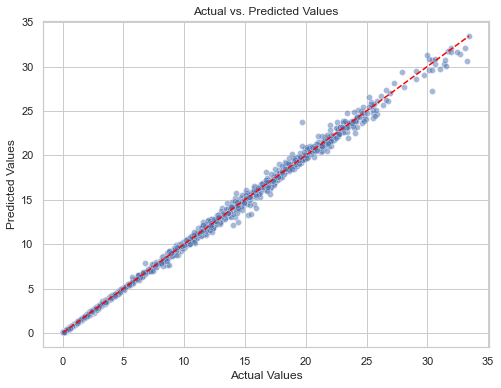

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for actual and predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Create the plot
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results_df, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # 45-degree line

# Add labels and title
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')

# Show the plot
plt.show()

### Inference : Points are tightly clustered around the 45-degree line. Hence the model is performing well